## EDA - Flights and Weather Data at JFK airport - Analysing Sandy Hurrican 2011 

In [42]:
## import dependencies

# Pandas for manipulation
import pandas as pd 
# SQLalchemy for connecting with SQL database and writing SQL queries
from sqlalchemy import create_engine, text 
# dotent to deal with credentials 
from dotenv import dotenv_values

In [43]:
## Connect with database
config = dotenv_values()

db_user   = config['POSTGRES_USER']
db_pw     = config['POSTGRES_PASS']
db_host   = config['POSTGRES_HOST']
db_port   = config['POSTGRES_PORT']
db_db     = config['POSTGRES_DB']
db_schema = config['POSTGRES_SCHEMA']
db        = 'postgresql'

In [44]:
## DATABASE URL -> PostgreSQL connection URL 
URL = f'{db}://{db_user}:{db_pw}@{db_host}:{db_port}/{db_db}'

In [45]:
## Create an engine with connection URL 
engine = create_engine(URL, echo=True)

In [46]:
## Set the schema search path 
with engine.begin() as con:
    result = con.execute(text(f'SET search_path TO {db_schema};'))
result

2025-09-15 18:14:30,475 INFO sqlalchemy.engine.Engine select pg_catalog.version()
2025-09-15 18:14:30,476 INFO sqlalchemy.engine.Engine [raw sql] {}
2025-09-15 18:14:30,562 INFO sqlalchemy.engine.Engine select current_schema()
2025-09-15 18:14:30,563 INFO sqlalchemy.engine.Engine [raw sql] {}
2025-09-15 18:14:30,710 INFO sqlalchemy.engine.Engine show standard_conforming_strings
2025-09-15 18:14:30,710 INFO sqlalchemy.engine.Engine [raw sql] {}
2025-09-15 18:14:30,778 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2025-09-15 18:14:30,783 INFO sqlalchemy.engine.Engine SET search_path TO clear_skies;
2025-09-15 18:14:30,785 INFO sqlalchemy.engine.Engine [generated in 0.00115s] {}
2025-09-15 18:14:30,853 INFO sqlalchemy.engine.Engine COMMIT


In [47]:
## Create a function to query 
def query_to_df(query: str)-> pd.DataFrame:
    '''
    This function takes a PostgreSQL Qurey and returns 
    a dataframe from the queried tabel. 

    NOTE: for this function to run you need Pandas and already a valid connection 
    to your DB with SQLalchemy
    '''
    with engine.begin() as con:
        call = con.execute(text(query))
    data = call.all()
    df = pd.DataFrame(data)

    return df

In [55]:
## FROM FLIGHTS FROM JFK OR TO 
df_flights = query_to_df(
    '''
        SELECT
            *
        FROM filtered_flights
    '''
)

2025-09-15 18:18:46,422 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2025-09-15 18:18:46,423 INFO sqlalchemy.engine.Engine 
        SELECT
            *
        FROM filtered_flights
    
2025-09-15 18:18:46,423 INFO sqlalchemy.engine.Engine [cached since 107.5s ago] {}
2025-09-15 18:18:47,345 INFO sqlalchemy.engine.Engine COMMIT


In [78]:
df_weather = query_to_df(
    '''
        SELECT
            airport_code, 
            station_id,
            CAST(date AS DATE) AS sensor_date,
            date_year,
            month_name,
            date_day,
            avg_temp_c,
            min_temp_c,
            max_temp_c,
            max_snow_mm,
            avg_wind_speed,
            precipitation_mm,
            avg_pressure_hpa
        FROM prep_weather_daily
    '''
)

2025-09-15 18:34:41,582 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2025-09-15 18:34:41,583 INFO sqlalchemy.engine.Engine 
        SELECT
            airport_code, 
            station_id,
            CAST(date AS DATE) AS sensor_date,
            date_year,
            month_name,
            date_day,
            avg_temp_c,
            min_temp_c,
            max_temp_c,
            max_snow_mm,
            avg_wind_speed,
            precipitation_mm,
            avg_pressure_hpa
        FROM prep_weather_daily
    
2025-09-15 18:34:41,583 INFO sqlalchemy.engine.Engine [cached since 14.7s ago] {}
2025-09-15 18:34:41,755 INFO sqlalchemy.engine.Engine COMMIT


In [79]:
print(f'Daily Weather data: {len(df_weather)}')
print(f'Daily flights data: {len(df_flights)}')

Daily Weather data: 183
Daily flights data: 108694


Flight data are much much abundant because there are multiple flights per day, whereas daily weather data consist of one aggregated observation per day.

## EDA

In [80]:
df_weather.head()

,airport_code,station_id,sensor_date,date_year,month_name,date_day,avg_temp_c,min_temp_c,max_temp_c,max_snow_mm,avg_wind_speed,precipitation_mm,avg_pressure_hpa
0,LGA,72503,2012-10-01,2012.0,October,1.0,17.8,12.8,22.2,0,17.6,0.0,1011.6
1,EWR,72502,2012-10-01,2012.0,October,1.0,16.6,10.0,22.8,0,14.8,0.0,1011.9
2,JFK,74486,2012-10-01,2012.0,October,1.0,17.1,12.2,22.2,0,18.4,0.0,1012.2
3,JFK,74486,2012-10-02,2012.0,October,2.0,18.8,17.2,21.7,0,9.4,8.4,1015.8
4,LGA,72503,2012-10-02,2012.0,October,2.0,18.8,17.2,21.1,0,10.8,9.9,1015.4


In [81]:
## Check Data Types and nulls
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183 entries, 0 to 182
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   airport_code      183 non-null    object 
 1   station_id        183 non-null    int64  
 2   sensor_date       183 non-null    object 
 3   date_year         183 non-null    float64
 4   month_name        183 non-null    object 
 5   date_day          183 non-null    float64
 6   avg_temp_c        183 non-null    object 
 7   min_temp_c        183 non-null    object 
 8   max_temp_c        183 non-null    object 
 9   max_snow_mm       183 non-null    int64  
 10  avg_wind_speed    183 non-null    object 
 11  precipitation_mm  183 non-null    object 
 12  avg_pressure_hpa  180 non-null    object 
dtypes: float64(2), int64(2), object(9)
memory usage: 18.7+ KB


- sensor date should be converted into pandas date data type (NOTE: the object is datetime.date but because I am working with pandas I converting to pandas datetime64) 
- date_day should be int 
- avg_temo_c, min_temp_c, max_temp_c, avg_wind_speed, precipitation_mm, avg_pressura_hpa should be floats

In [100]:
## converting data types to be applicable for pandas
## Converts to date 
def to_date(df: pd.DataFrame, col_name: str):
    '''
        Converts a column to date
    '''
    df[col_name] = pd.to_datetime(df[col_name])

## convert a column to flaot data type 
def to_float(df: pd.DataFrame, col_name: str):
    '''
        Converts a column to float 
    '''
    df[col_name] = df[col_name].astype(float)

## convert a column to int data type 
def to_int(df: pd.DataFrame, col_name: str):
    '''
        Converts a column to float
    '''
    df[col_name] = df[col_name].astype(int)

In [107]:
## Converting the data 
to_date(df_weather, 'sensor_date')

to_float(df_weather, 'avg_temp_c')
to_float(df_weather, 'min_temp_c')
to_float(df_weather, 'max_temp_c')
to_float(df_weather, 'max_snow_mm')
to_float(df_weather, 'avg_wind_speed')
to_float(df_weather, 'precipitation_mm')
to_float(df_weather, 'avg_pressure_hpa')

to_int(df_weather, 'date_day')
to_int(df_weather, 'date_year')

In [108]:
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183 entries, 0 to 182
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   airport_code      183 non-null    object        
 1   station_id        183 non-null    int64         
 2   sensor_date       183 non-null    datetime64[ns]
 3   date_year         183 non-null    int64         
 4   month_name        183 non-null    object        
 5   date_day          183 non-null    int64         
 6   avg_temp_c        183 non-null    float64       
 7   min_temp_c        183 non-null    float64       
 8   max_temp_c        183 non-null    float64       
 9   max_snow_mm       183 non-null    float64       
 10  avg_wind_speed    183 non-null    float64       
 11  precipitation_mm  183 non-null    float64       
 12  avg_pressure_hpa  180 non-null    float64       
dtypes: datetime64[ns](1), float64(7), int64(3), object(2)
memory usage: 18.7+ KB


In [ ]:
weather_data_nulls = df_weather.isna().sum()
weather_dublicated = df_weather.duplicated().sum()

# flight_filtered_dates = df_flights_jfk[df_flights_jfk['flight_date'] > '2012-11-01']
import datetime
flight_filtered_dates  = df_flights_jfk[(df_flights_jfk['flight_date'] > datetime.datetime(2012,10,20)) & (df_flights_jfk['flight_date'] < datetime.datetime(2012,11,20))]

## Filter the data for a better readability
weather_filtered_dates  = df_weather_jfk[(df_weather_jfk['sensor_date'] > datetime.date(2012,10,20)) & (df_weather_jfk['sensor_date'] < datetime.date(2012,11,20))]

In [19]:
df_weather_jfk.head()

,airport_code,station_id,sensor_date,date_year,month_name,date_day,avg_temp_c,min_temp_c,max_temp_c,max_snow_mm,avg_wind_speed,precipitation_mm,avg_pressure_hpa
0,LGA,72503,2012-10-01,2012.0,October,1.0,17.8,12.8,22.2,0,17.6,0.0,1011.6
1,EWR,72502,2012-10-01,2012.0,October,1.0,16.6,10.0,22.8,0,14.8,0.0,1011.9
2,JFK,74486,2012-10-01,2012.0,October,1.0,17.1,12.2,22.2,0,18.4,0.0,1012.2
3,JFK,74486,2012-10-02,2012.0,October,2.0,18.8,17.2,21.7,0,9.4,8.4,1015.8
4,LGA,72503,2012-10-02,2012.0,October,2.0,18.8,17.2,21.1,0,10.8,9.9,1015.4


In [20]:
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

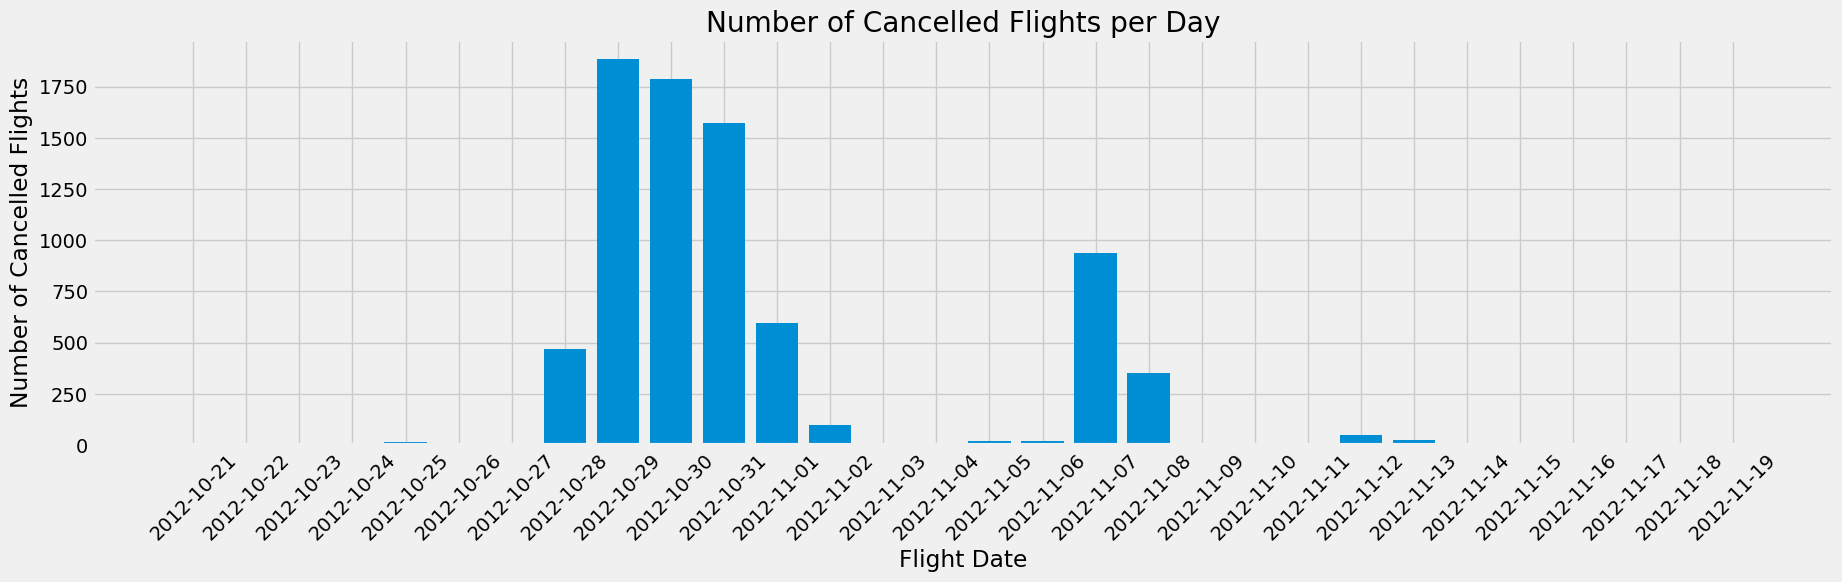

In [21]:
cancelled_per_day = flight_filtered_dates.groupby('flight_date')['cancelled'].sum()

fig, ax = plt.subplots(figsize=(20,5))
ax.bar(cancelled_per_day.index, cancelled_per_day.values)
ax.set_xlabel('Flight Date')
ax.set_ylabel('Number of Cancelled Flights')
ax.set_title('Number of Cancelled Flights per Day')
ax.set_xticks(cancelled_per_day.index)
plt.xticks(rotation=45)
plt.show()

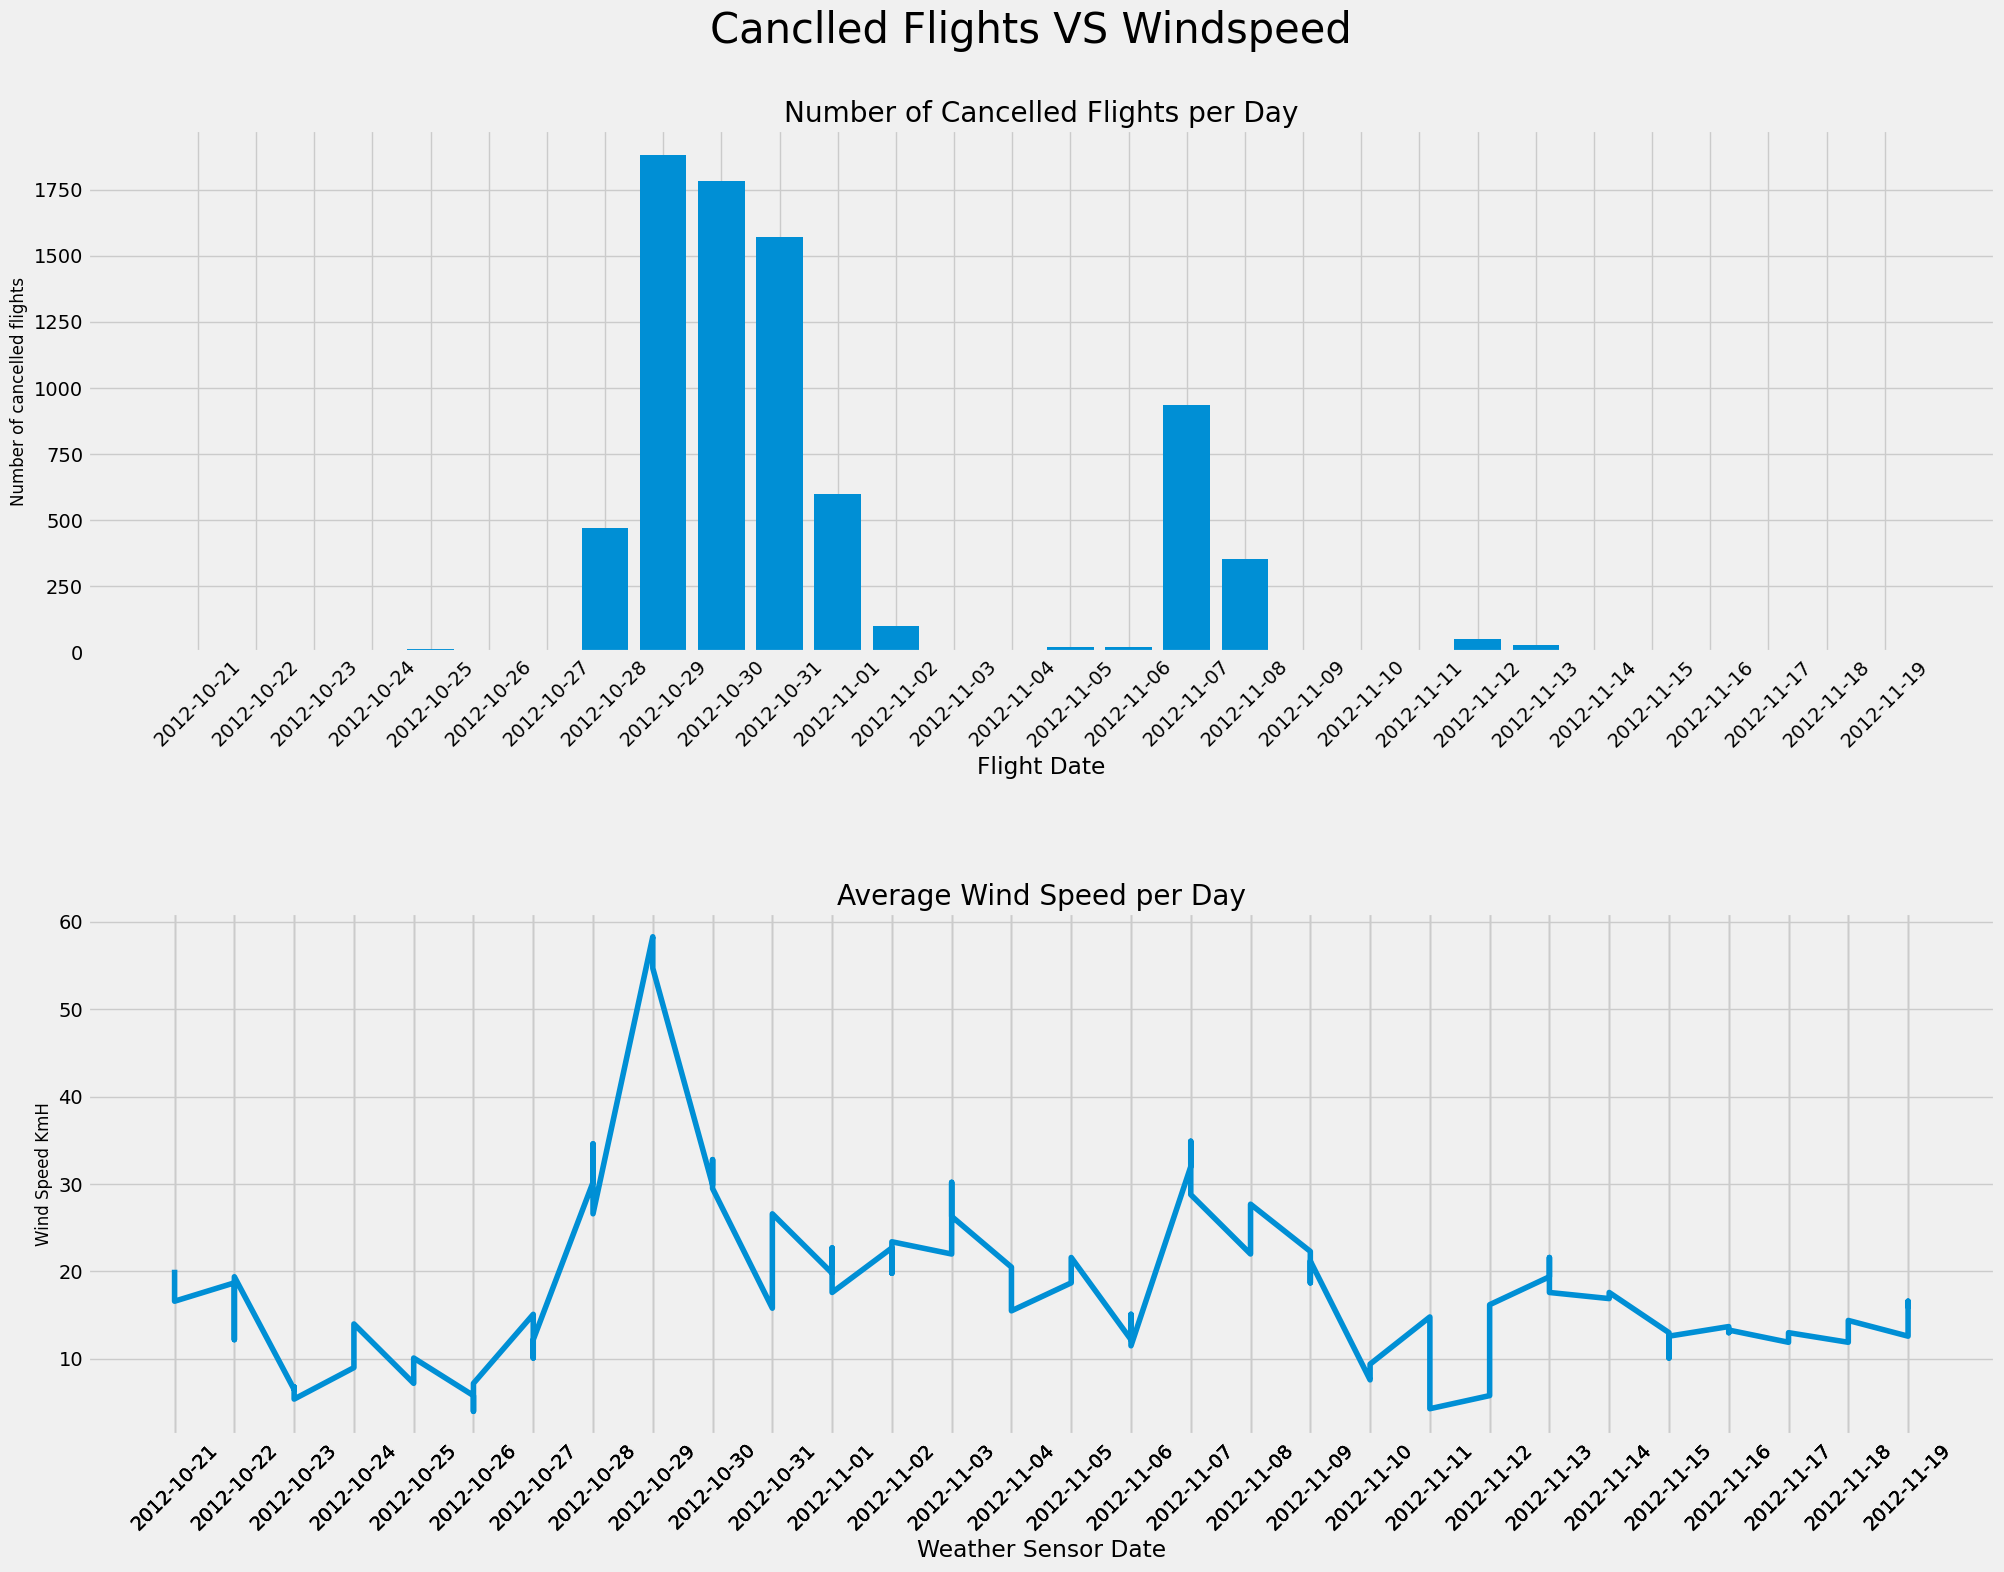

In [22]:
fig, ax = plt.subplots(2,1, figsize=(20,15))
plt.suptitle('Canclled Flights VS Windspeed', fontsize=30)
fig.tight_layout()
plt.subplots_adjust(hspace=.5, wspace=.2, top=.9)

ax[0].bar(cancelled_per_day.index, cancelled_per_day.values)
ax[0].set_xticks(cancelled_per_day.index)
ax[0].set_xlabel('Flight Date')
ax[0].set_ylabel('Number of cancelled flights', fontsize=12)
ax[0].set_title('Number of Cancelled Flights per Day')
ax[0].tick_params(axis='x', rotation=45)

ax[1].plot(weather_filtered_dates['sensor_date'].sort_values(ascending=True), weather_filtered_dates['avg_wind_speed'])
ax[1].set_xticks(weather_filtered_dates['sensor_date'])
ax[1].set_xlabel('Weather Sensor Date')
ax[1].set_ylabel('Wind Speed KmH', fontsize=12)
ax[1].set_title('Average Wind Speed per Day')
ax[1].tick_params(axis='x', rotation=45)

In [23]:
flight_filtered_dates.head()

,flight_date,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,airline,tail_number,flight_number,origin,dest,air_time,actual_elapsed_time,distance,cancelled,diverted
6931,2012-10-25,NaN,1530,NaN,NaN,1845,NaN,AA,N389AA,85,JFK,SFO,NaN,NaN,2586,1,0
12639,2012-10-25,NaN,1839,NaN,NaN,2028,NaN,EV,N16951,4092,DAY,EWR,NaN,NaN,533,1,0
15193,2012-10-27,2232.0,2030,122.0,NaN,2315,NaN,AA,N3FJAA,1226,MIA,LGA,NaN,NaN,1096,0,1
16019,2012-10-28,NaN,1654,NaN,NaN,1807,NaN,EV,N10575,4695,BWI,EWR,NaN,NaN,169,1,0
17296,2012-10-28,NaN,1815,NaN,NaN,2005,NaN,MQ,N510MQ,4626,LGA,CMH,NaN,NaN,479,1,0


In [24]:
weather_filtered_dates.head()

,airport_code,station_id,sensor_date,date_year,month_name,date_day,avg_temp_c,min_temp_c,max_temp_c,max_snow_mm,avg_wind_speed,precipitation_mm,avg_pressure_hpa
60,LGA,72503,2012-10-21,2012.0,October,21.0,15.0,11.1,18.9,0,20.2,0.0,1013.6
61,JFK,74486,2012-10-21,2012.0,October,21.0,14.7,10.6,20.0,0,18.4,0.0,1014.1
62,EWR,72502,2012-10-21,2012.0,October,21.0,14.2,9.4,20.6,0,16.6,0.0,1014.0
63,JFK,74486,2012-10-22,2012.0,October,22.0,15.8,10.6,20.6,0,18.7,0.0,1017.9
64,EWR,72502,2012-10-22,2012.0,October,22.0,15.4,9.4,21.7,0,12.2,0.0,1017.8


In [25]:
sum(cancelled_per_day)

7922

In [26]:
merged_df = pd.merge(
    cancelled_per_day,
    weather_filtered_dates,
    left_on='flight_date',
    right_on='sensor_date',
    how='inner' 
)

ValueError: You are trying to merge on datetime64[ns] and object columns for key 'flight_date'. If you wish to proceed you should use pd.concat

In [27]:
selected_cols = ['cancelled','avg_temp_c','min_temp_c','max_temp_c','max_snow_mm','avg_wind_speed','precipitation_mm','avg_pressure_hpa']
new_df = merged_df[selected_cols].copy()
new_df

NameError: name 'merged_df' is not defined

In [28]:
## 2012-10-21 to 2012-11-19	
correlation_matrix = new_df.corr()
correlation_matrix

NameError: name 'new_df' is not defined

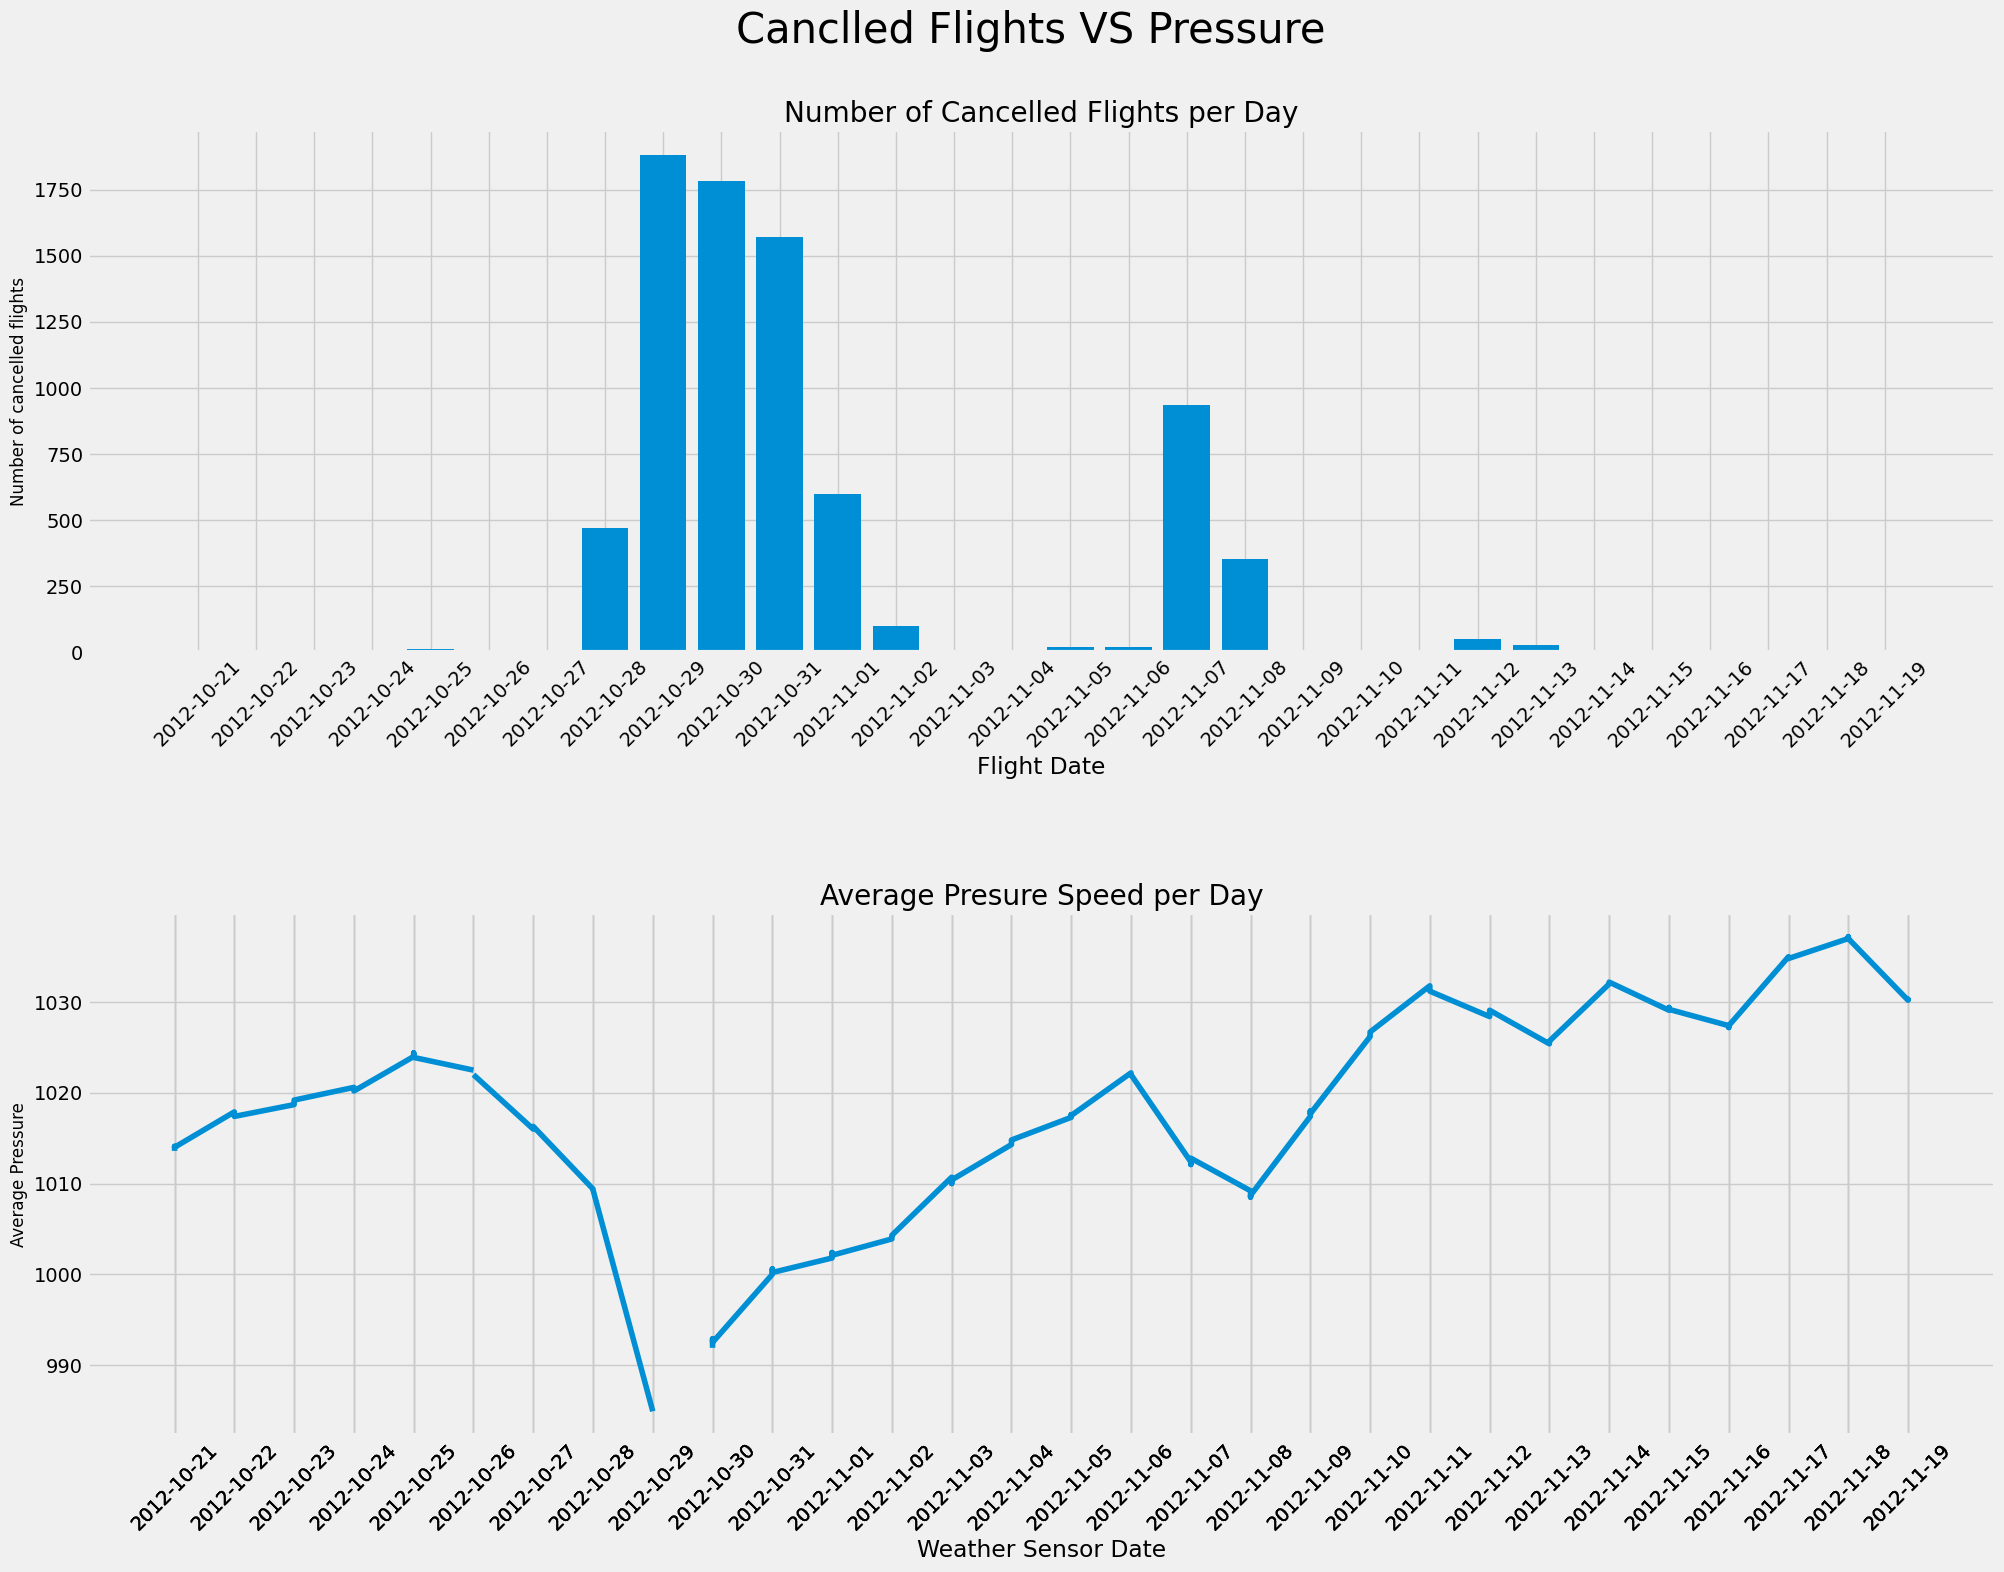

In [29]:
fig, ax = plt.subplots(2,1, figsize=(20,15))
plt.suptitle('Canclled Flights VS Pressure', fontsize=30)
fig.tight_layout()
plt.subplots_adjust(hspace=.5, wspace=.2, top=.9)

ax[0].bar(cancelled_per_day.index, cancelled_per_day.values)
ax[0].set_xticks(cancelled_per_day.index)
ax[0].set_xlabel('Flight Date')
ax[0].set_ylabel('Number of cancelled flights', fontsize=12)
ax[0].set_title('Number of Cancelled Flights per Day')
ax[0].tick_params(axis='x', rotation=45)

ax[1].plot(weather_filtered_dates['sensor_date'].sort_values(ascending=True), weather_filtered_dates['avg_pressure_hpa'])
ax[1].set_xticks(weather_filtered_dates['sensor_date'])
ax[1].set_xlabel('Weather Sensor Date')
ax[1].set_ylabel('Average Pressure', fontsize=12)
ax[1].set_title('Average Presure Speed per Day')
ax[1].tick_params(axis='x', rotation=45)

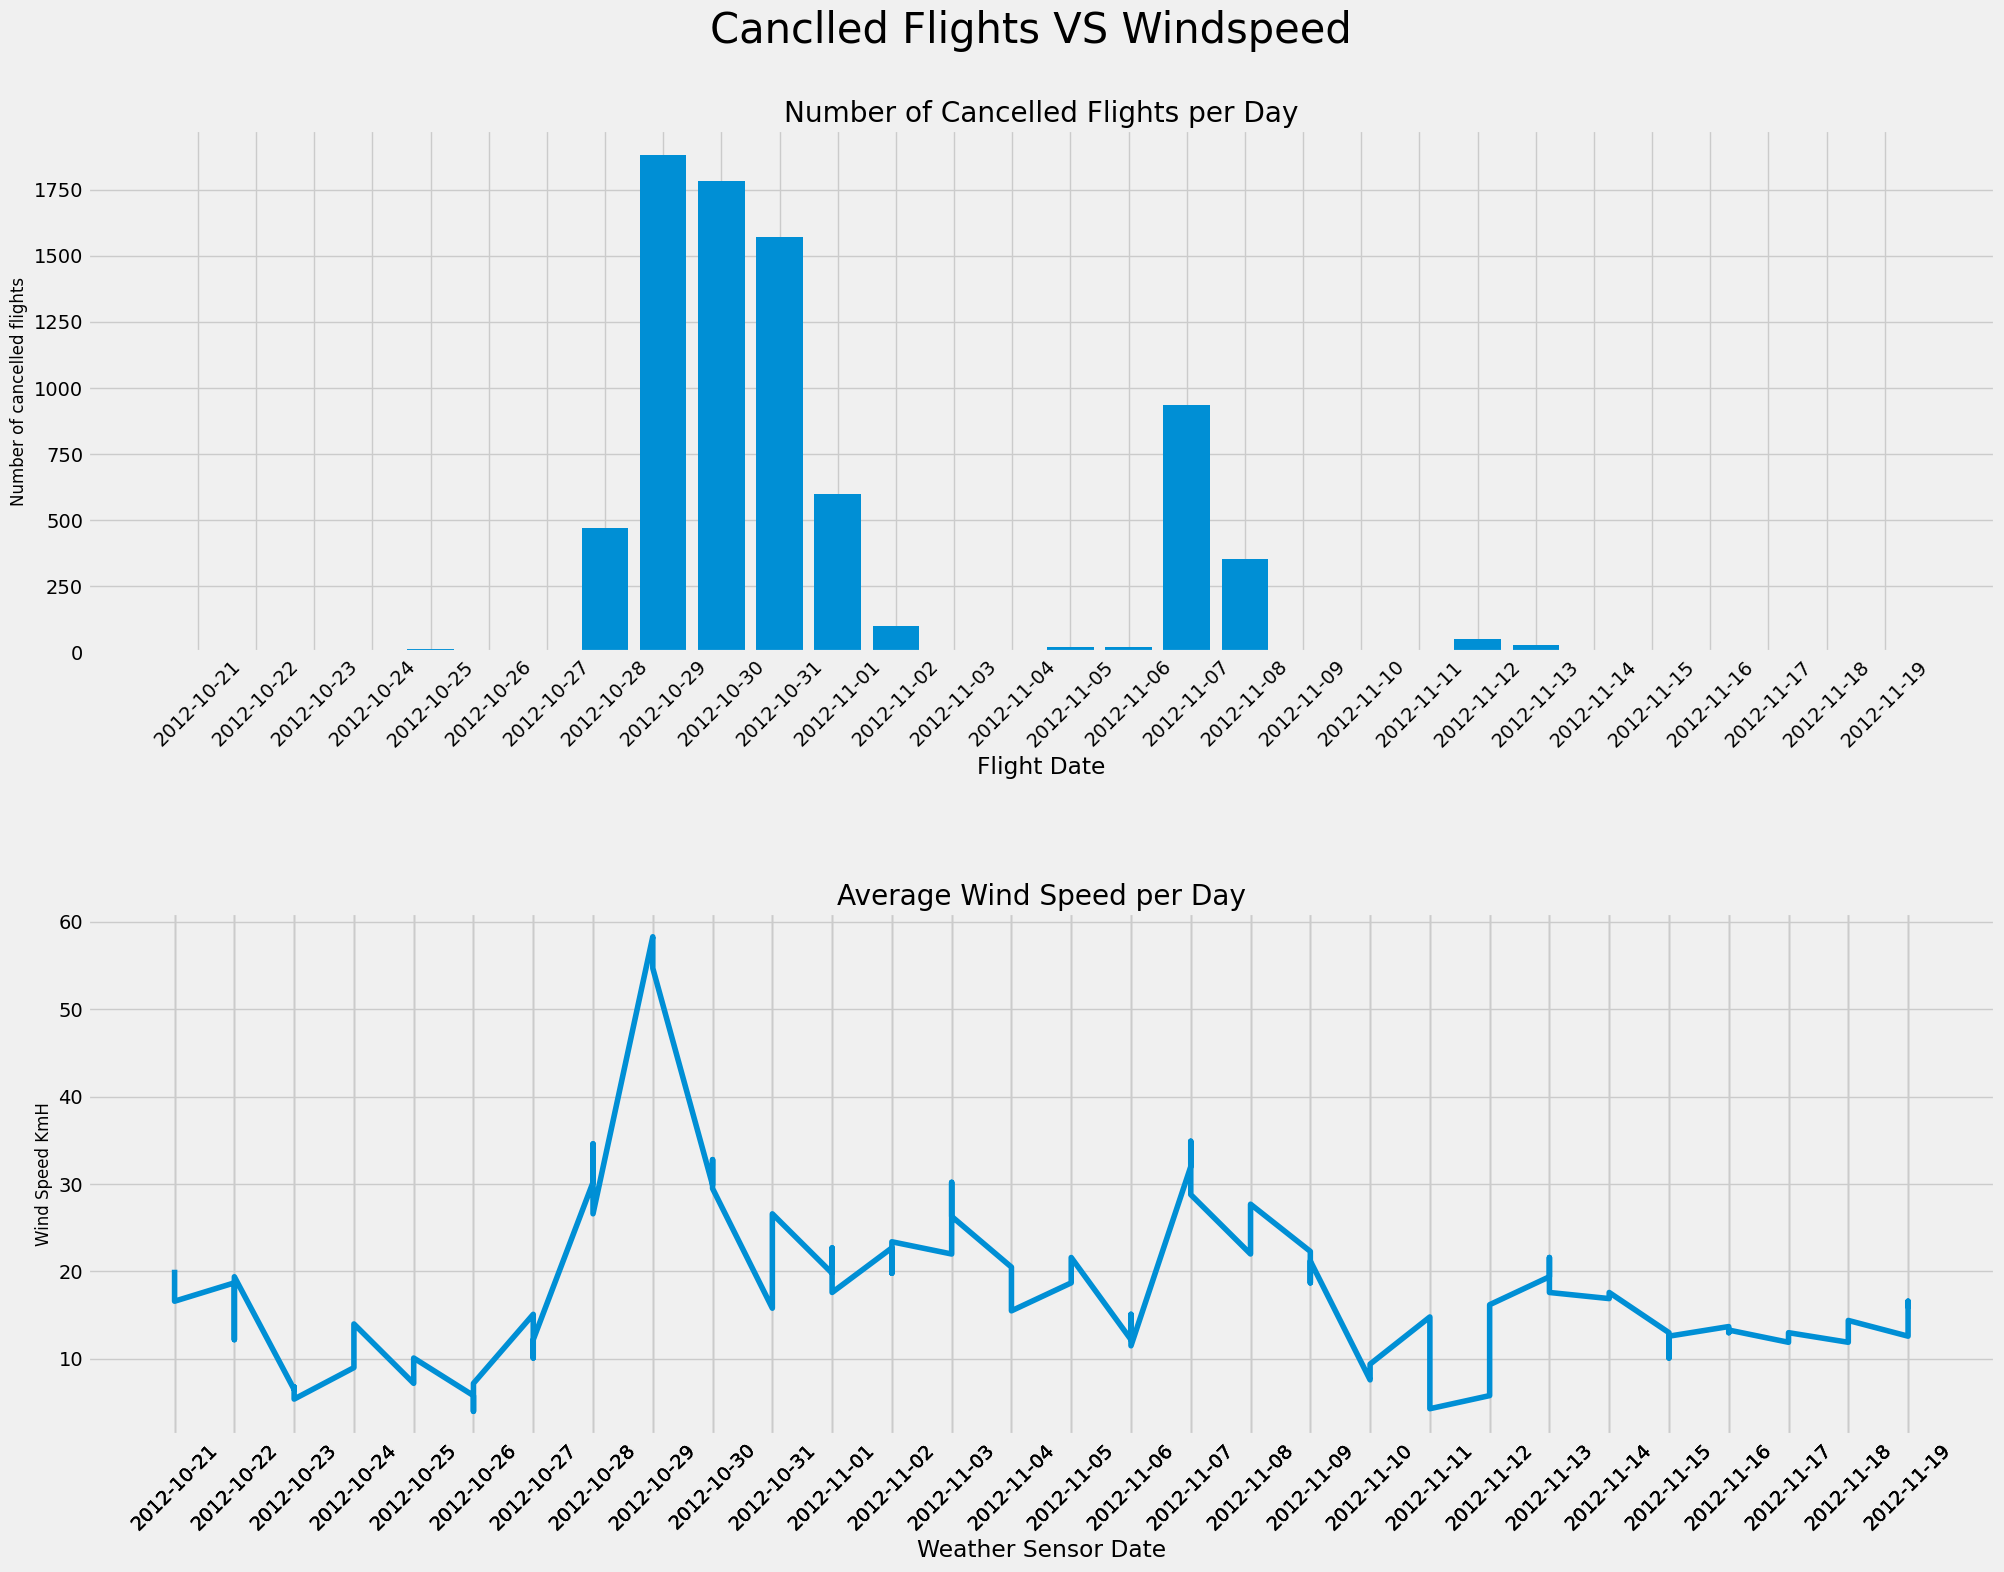

In [30]:
fig, ax = plt.subplots(2,1, figsize=(20,15))
plt.suptitle('Canclled Flights VS Windspeed', fontsize=30)
fig.tight_layout()
plt.subplots_adjust(hspace=.5, wspace=.2, top=.9)

ax[0].bar(cancelled_per_day.index, cancelled_per_day.values)
ax[0].set_xticks(cancelled_per_day.index)
ax[0].set_xlabel('Flight Date')
ax[0].set_ylabel('Number of cancelled flights', fontsize=12)
ax[0].set_title('Number of Cancelled Flights per Day')
ax[0].tick_params(axis='x', rotation=45)

ax[1].plot(weather_filtered_dates['sensor_date'].sort_values(ascending=True), weather_filtered_dates['avg_wind_speed'])
ax[1].set_xticks(weather_filtered_dates['sensor_date'])
ax[1].set_xlabel('Weather Sensor Date')
ax[1].set_ylabel('Wind Speed KmH', fontsize=12)
ax[1].set_title('Average Wind Speed per Day')
ax[1].tick_params(axis='x', rotation=45)

NameError: name 'new_df' is not defined

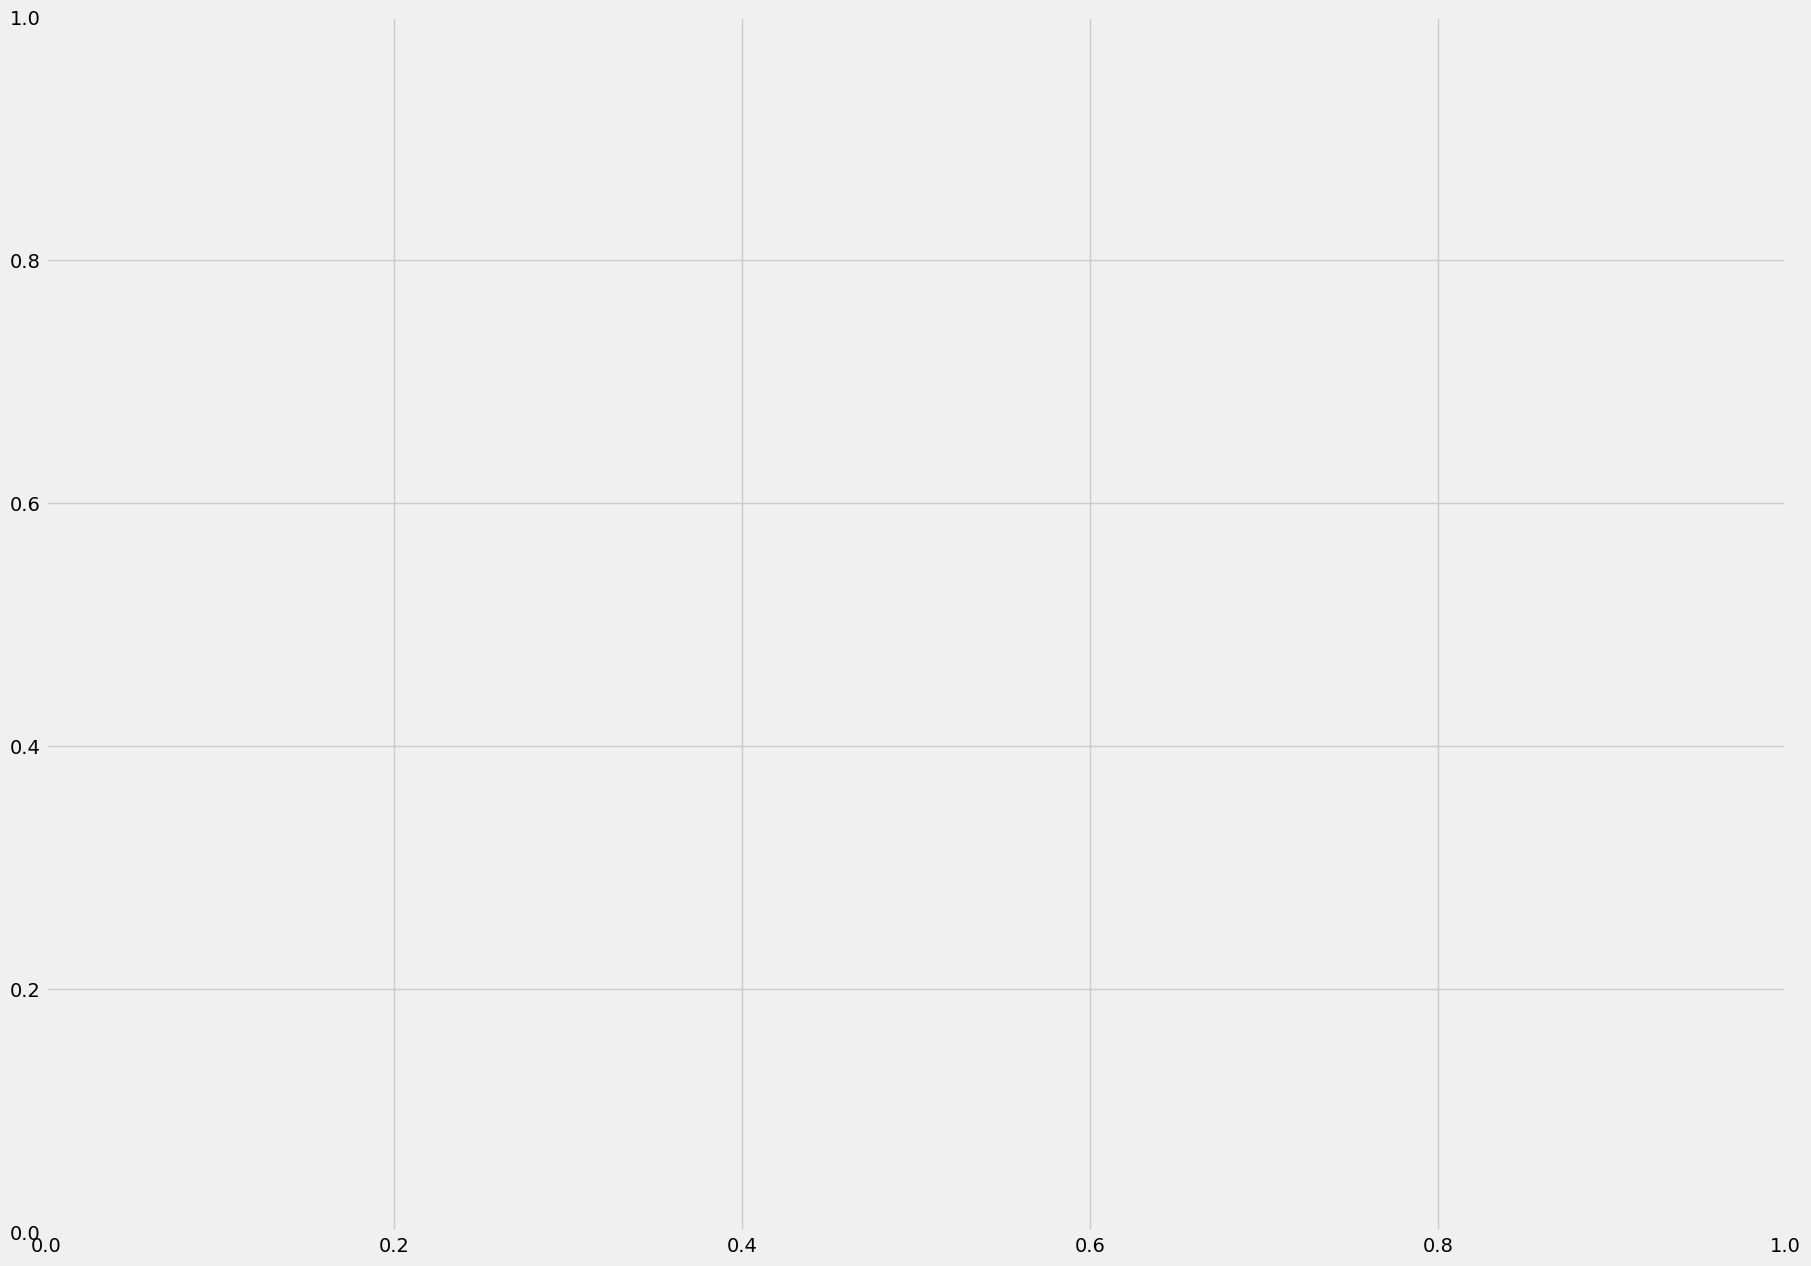

In [31]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(20,15))
ax = sns.heatmap(new_df.corr())


In [ ]:
fig, ax = plt.subplots(2,1, figsize=(20,15))
plt.suptitle('Canclled Flights VS Snow', fontsize=30)
fig.tight_layout()
plt.subplots_adjust(hspace=.5, wspace=.2, top=.9)

ax[0].bar(cancelled_per_day.index, cancelled_per_day.values)
ax[0].set_xticks(cancelled_per_day.index)
ax[0].set_xlabel('Flight Date')
ax[0].set_ylabel('Number of cancelled flights', fontsize=12)
ax[0].set_title('Number of Cancelled Flights per Day')
ax[0].tick_params(axis='x', rotation=45)

ax[1].plot(weather_filtered_dates['sensor_date'].sort_values(ascending=True), weather_filtered_dates['max_snow_mm'])
ax[1].set_xticks(weather_filtered_dates['sensor_date'])
ax[1].set_xlabel('Weather Sensor Date')
ax[1].set_ylabel('Snow mm', fontsize=12)
ax[1].set_title('Max Snow per Day')
ax[1].tick_params(axis='x', rotation=45)

In [ ]:
import datetime
flight_focused_dates  = df_flights_jfk[(df_flights_jfk['flight_date'] > datetime.datetime(2012,11,2)) & (df_flights_jfk['flight_date'] < datetime.datetime(2012,11,13))]

## Filter the data for a better readability
weather_focused_dates  = df_weather_jfk[(df_weather_jfk['sensor_date'] > datetime.date(2012,11,2)) & (df_weather_jfk['sensor_date'] < datetime.date(2012,11,13))]

cancelled_per_day = flight_focused_dates.groupby('flight_date')['cancelled'].sum()


NameError: name 'weather_focused_dates' is not defined

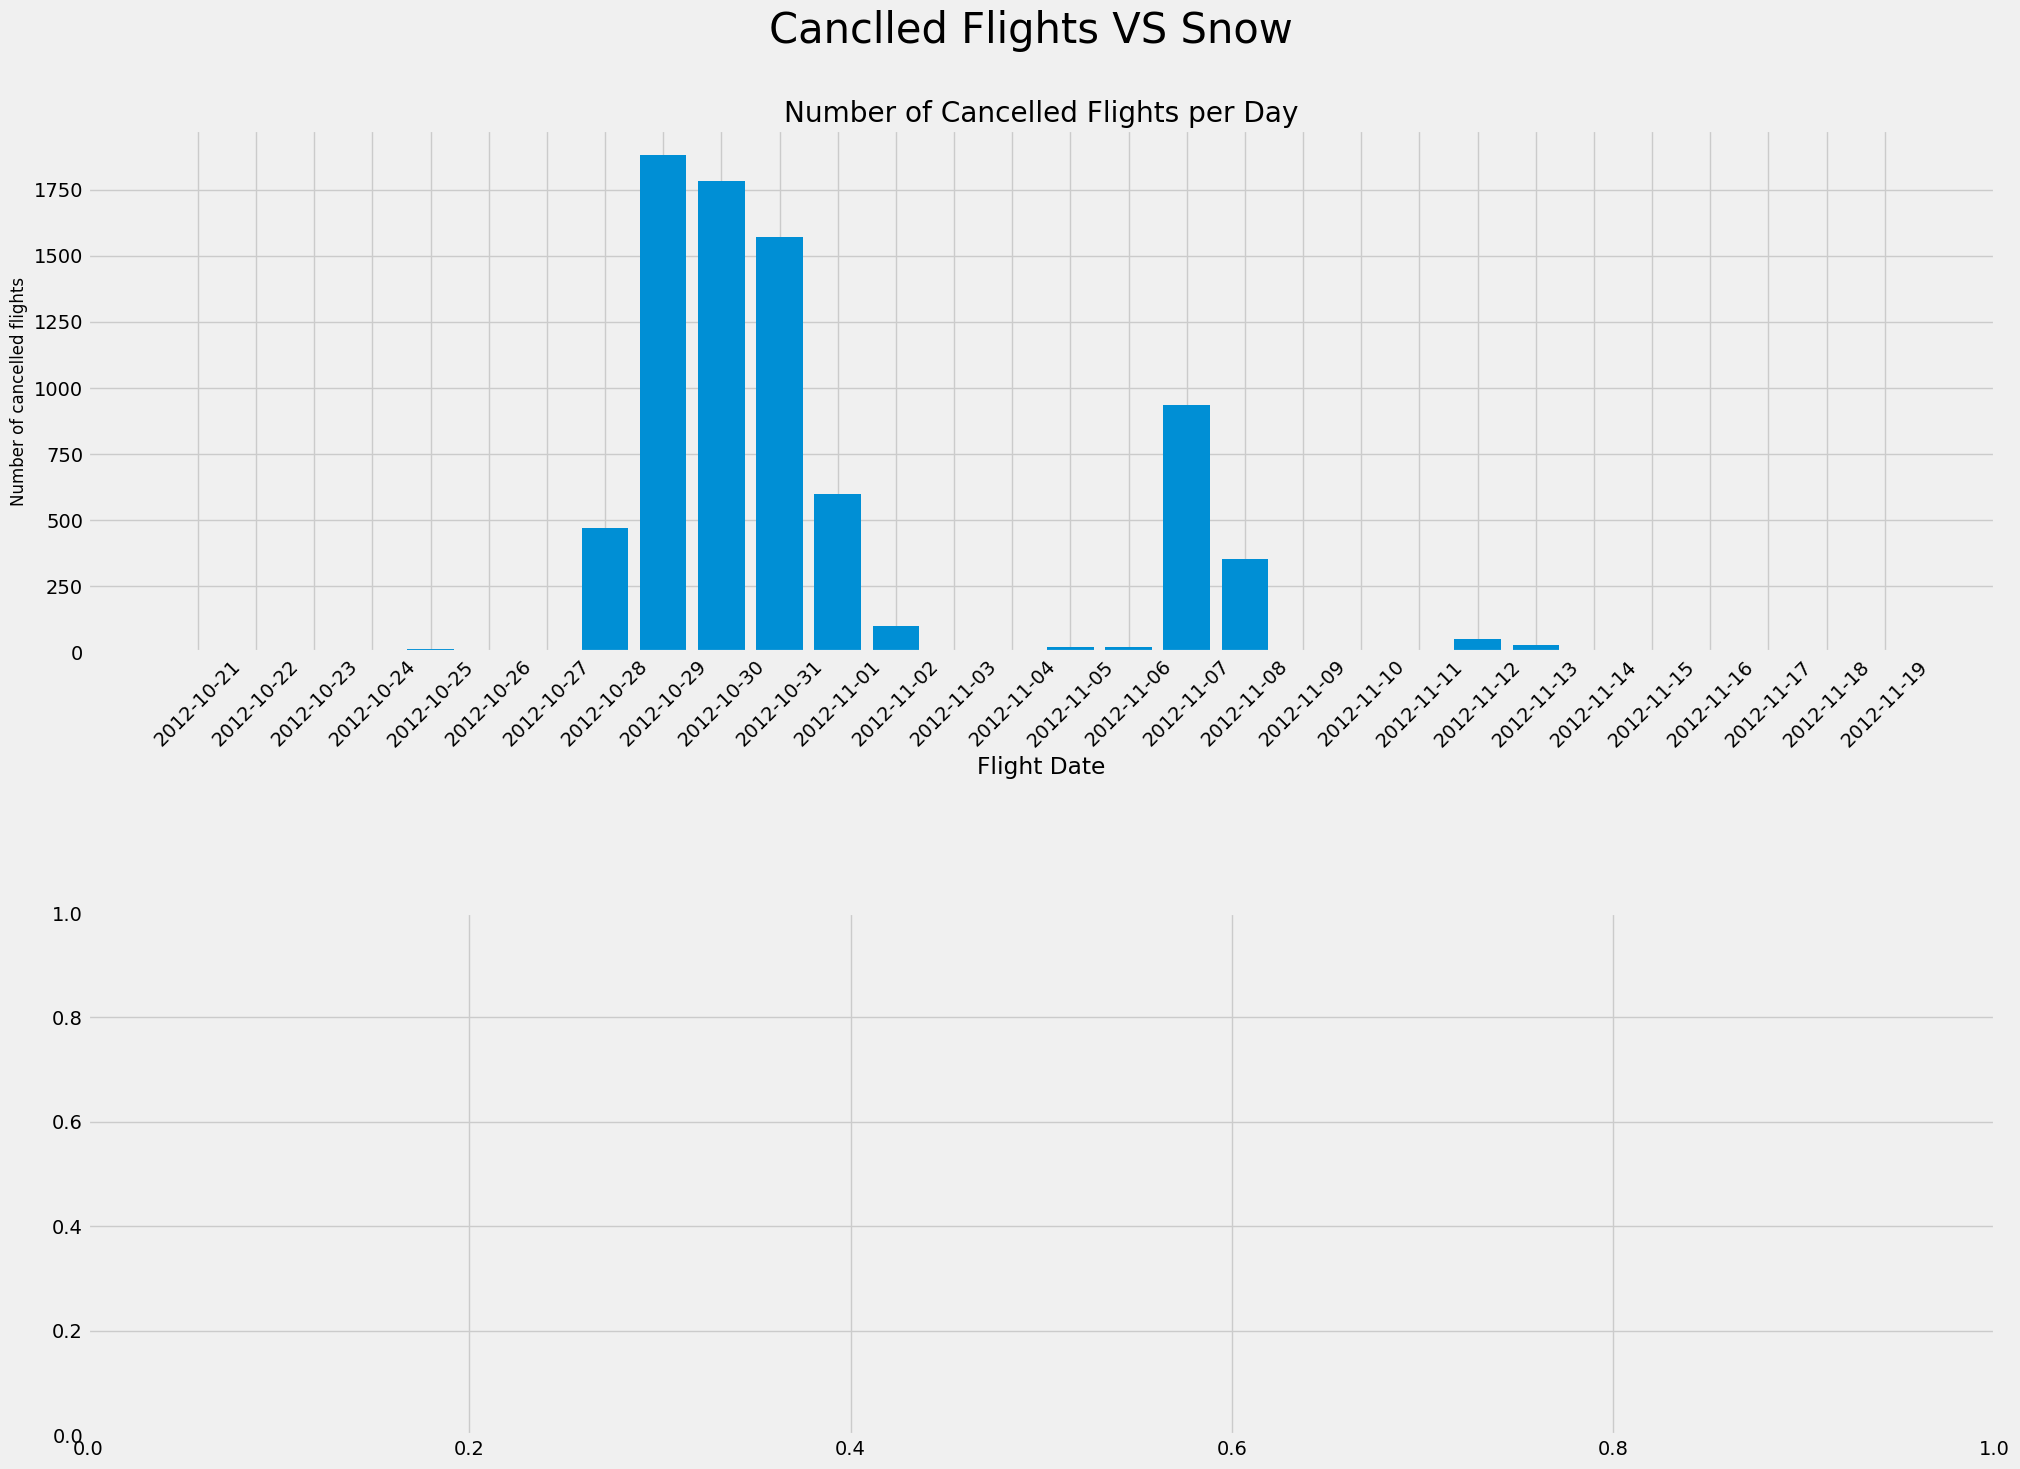

In [32]:
fig, ax = plt.subplots(2,1, figsize=(20,15))
plt.suptitle('Canclled Flights VS Snow', fontsize=30)
fig.tight_layout()
plt.subplots_adjust(hspace=.5, wspace=.2, top=.9)

ax[0].bar(cancelled_per_day.index, cancelled_per_day.values)
ax[0].set_xticks(cancelled_per_day.index)
ax[0].set_xlabel('Flight Date')
ax[0].set_ylabel('Number of cancelled flights', fontsize=12)
ax[0].set_title('Number of Cancelled Flights per Day')
ax[0].tick_params(axis='x', rotation=45)

ax[1].plot(weather_focused_dates['sensor_date'].sort_values(ascending=True), weather_focused_dates['avg_wind_speed'])
ax[1].set_xticks(weather_focused_dates['sensor_date'])
ax[1].set_xlabel('Weather Sensor Date')
ax[1].set_ylabel('Snow mm', fontsize=12)
ax[1].set_title('Max Snow per Day')
ax[1].tick_params(axis='x', rotation=45)

In [33]:
# 25.10.2012
# 10.11.2012

flight_dates_canc_num = df_flights_jfk[(df_flights_jfk['flight_date'] > datetime.datetime(2012,10,25)) & (df_flights_jfk['flight_date'] < datetime.datetime(2012,11,10))]
flight_dates_canc_num

,flight_date,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,airline,tail_number,flight_number,origin,dest,air_time,actual_elapsed_time,distance,cancelled,diverted
15193,2012-10-27,2232.0,2030,122.0,NaN,2315,NaN,AA,N3FJAA,1226,MIA,LGA,NaN,NaN,1096,0,1
16019,2012-10-28,NaN,1654,NaN,NaN,1807,NaN,EV,N10575,4695,BWI,EWR,NaN,NaN,169,1,0
17296,2012-10-28,NaN,1815,NaN,NaN,2005,NaN,MQ,N510MQ,4626,LGA,CMH,NaN,NaN,479,1,0
24722,2012-10-28,NaN,1815,NaN,NaN,2015,NaN,MQ,N509MQ,4580,CLT,LGA,NaN,NaN,544,1,0
26454,2012-10-28,NaN,1900,NaN,NaN,2209,NaN,UA,None,614,ORD,LGA,NaN,NaN,733,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71914,2012-11-09,2339.0,2345,-6.0,740.0,759,-19.0,VX,N635VA,420,LAX,JFK,275.0,301.0,2475,0,0
71915,2012-11-09,51.0,2350,61.0,728.0,609,79.0,DL,N391DA,1002,SLC,JFK,226.0,277.0,1990,0,0
71916,2012-11-09,2354.0,2359,-5.0,425.0,437,-12.0,B6,N605JB,727,JFK,BQN,195.0,211.0,1576,0,0
71917,2012-11-09,2357.0,2359,-2.0,443.0,445,-2.0,B6,N615JB,739,JFK,PSE,203.0,226.0,1617,0,0


In [34]:
len(flight_dates_canc_num)
cancelled_flights = flight_dates_canc_num[flight_dates_canc_num['cancelled'] == 1]
sum_cancelled = sum(cancelled_flights['cancelled'])
sum_cancelled

7768

In [37]:
len(df_flights_jfk)

108694

In [38]:
all_flights = len(flight_dates_canc_num)

In [39]:
percentage_canceled = sum_cancelled/all_flights

In [40]:
round(percentage_canceled * 100,2)

29.12

In [41]:
sum_cancelled

7768